In [2]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
from tqdm import *
from numpy.linalg import eigh
import matplotlib.pyplot as plt

In [3]:
def concat_model_4fold(test_path, res_path):
    market = 'ALL'
    model_res = []
    for valid_period in ['validperiod1', 'validperiod2', 'validperiod3', 'validperiod4']:
        data_path = rf"{test_path}/{market}-{valid_period}"
        date_list = list(set([x[:8] for x in os.listdir(data_path)]))
        date_list.sort()
        all_res = []
        for date in date_list:
            date_res = pd.read_pickle(f'{data_path}/{date}.pkl').T
            date_res.index = [date] * len(date_res)
            all_res.append(date_res)
        all_res = pd.concat(all_res, axis=0).sort_index()
        all_res.index.name = "date"
        all_res = all_res.apply(lambda x: (x - x.mean()) / x.std(), axis=1)
        model_res.append(all_res)
        
    model_res = sum(model_res)
    model_res.reset_index().to_feather(rf"{res_path}/{market}_all_score.fea")
    return model_res

# 根据模型打分获取对应的label_ret和ic
def get_ret_ic(score, ret_data, liquid_data, start='20230101', end='20250630', money=1.5e9, print_quarterly=False):
    model_score = score.copy()
    label_ret = []
    ic = []
    datelist = []
    # 这是一段日度调仓计算日度收益率的代码
    for date in model_score.loc[start:end].index:
        datelist.append(date)
        code_rank = model_score.loc[date].sort_values(ascending=False)
        ret = ret_data.loc[date].reindex(code_rank.index).fillna(0) * 100
        liquid = liquid_data.loc[date].reindex(code_rank.index).fillna(0)
        total_hold = 0
        total_earned = 0
        for num,code in enumerate(code_rank.index):
            if num >= 500:
                break
            if (money - total_hold) < 1:
                break
            hold_money = min(money - total_hold, liquid[code])
            total_hold += hold_money
            total_earned += ret[code] * hold_money
        total_ret = total_earned / money
        label_ret.append(total_ret)
        ic.append(code_rank.corr(ret))
    ic = pd.Series(ic, index=datelist, dtype='float')
    label_ret = pd.Series(label_ret, index=datelist, dtype='float')
    if print_quarterly:
        print_quarterly_metrics(label_ret, ic)
    return label_ret, ic

def print_quarterly_metrics(ret, ic):
    """打印每个季度的收益和IC指标"""
    ret_series = ret.copy()
    ic_series = ic.copy()
    ret_series.index = pd.to_datetime(ret_series.index)
    ic_series.index = pd.to_datetime(ic_series.index)
    quarterly_ret = ret_series.groupby(pd.Grouper(freq='QE')).mean()
    quarterly_ic = ic_series.groupby(pd.Grouper(freq='QE')).mean()
    quarterly_ret.index = [f"{idx.year}Q{idx.quarter}" for idx in quarterly_ret.index]
    quarterly_ic.index = [f"{idx.year}Q{idx.quarter}" for idx in quarterly_ic.index]
    quarterly_df = pd.DataFrame({
        '季度平均收益(%)': quarterly_ret.round(4),
        '季度平均IC': quarterly_ic.round(4)
    })
    print("\n===== 季度表现指标 =====")
    print(quarterly_df)
    print("=======================\n")

def get_metrics(score, ret_data, liquid_data, start='20230101', end='20250630', money=1.5e9, print_quarterly=True):
    ret_list, ic_list = get_ret_ic(score, ret_data, liquid_data, start=start, end=end, money=money, print_quarterly=print_quarterly)
    # 当前模型评价
    score_metrics = {
        "IC": ic_list.mean(),
        "ICIR": ic_list.mean() / ic_list.std() if ic_list.std() != 0 else 0,
        "top_return": ret_list.mean(),
        "top_return_stability": ret_list.mean() / ret_list.std() if ret_list.std() != 0 else 0
    }
    return score_metrics

def print_metrics(model_metrics, bench_metrics=None, title="模型评估结果"):
    metric_keys = list(model_metrics.keys())
    df = pd.DataFrame(index=metric_keys)
    df.index.name = "指标"
    df["模型值"] = [model_metrics[k] for k in metric_keys]
    if bench_metrics is not None:
        df["基准值"] = [bench_metrics.get(k, None) for k in metric_keys]
        df["提升值"] = ((df["模型值"] - df["基准值"]) / df["基准值"]) * 100
    print(f"\n{title}")
    print(df.round(4))

def plot_model(model_score, bench_score, ret_data, liquid_data, start='20230101', end='20250630', money=1.5e9):
    model_ret, _ = get_ret_ic(model_score, ret_data, liquid_data, start=start, end=end, money=money, print_quarterly=False)
    model_ret = model_ret/100
    bench_ret, _ = get_ret_ic(bench_score, ret_data, liquid_data, start=start, end=end, money=money, print_quarterly=False)
    bench_ret = bench_ret/100

    dates = model_ret.index.tolist()
    seen_months = set()
    month_ticks = []
    month_labels = []
    for i, d in enumerate(dates):
        month = d[:6] 
        if month not in seen_months:
            seen_months.add(month)
            month_ticks.append(i)
            month_labels.append(d)

    # 1. 绘制每日收益率曲线
    plt.figure(figsize=(12, 6))
    plt.plot(dates, model_ret.cumsum(), label='model', color='blue')
    plt.plot(dates, bench_ret.cumsum(), label='bench', color='orange')
    plt.title('Cumulative Return Of Model & Bench', fontsize=14)
    plt.ylabel('Cumulative Return(%)', fontsize=12)
    plt.xticks(ticks=month_ticks, labels=month_labels, rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # 2. 绘制相对提升
    plt.figure(figsize=(12, 6))
    relative_improvement = model_ret - bench_ret
    plt.plot(dates, relative_improvement.cumsum(), label='model', color='blue')
    plt.title('Relative Iprovement', fontsize=14)
    plt.ylabel('Relative Iprovement(%)', fontsize=12)
    plt.xticks(ticks=month_ticks, labels=month_labels, rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

def diversity_entropy(score):
    """
    计算 DE
    """
    if isinstance(score, pd.DataFrame):
        score = score.values
    m = score.shape[1]
    cov_matrix = np.cov(score, rowvar=False)
    eigenvalues, _ = eigh(cov_matrix)
    eigenvalues = np.sort(eigenvalues)[::-1]
    normalized_eigenvalues = eigenvalues / (np.sum(eigenvalues) + 1e-10)
    entropy = 0
    for p in normalized_eigenvalues:
        if p > 1e-10:  # 只对非零概率计算
            entropy -= p * np.log(p)
    de = entropy / np.log(m)
    return de

def ensemble_scores(*dfs):
    """
    输入：任意数量的打分 DataFrame（index=日期，columns=股票）
    输出：拼接后的 DataFrame，columns=score1, score2, ...
    """
    result_list = []
    for i, df in enumerate(dfs, 1):
        df_norm = df.copy()
        df_norm = df_norm.apply(lambda x: (x - x.mean()) / x.std(), axis=1)
        df_norm = df_norm.stack().rename(f"score{i}")
        result_list.append(df_norm)
    result = pd.concat(result_list, axis=1)
    return result.dropna()

# Bench_Mark_share1（5sub_score）

In [4]:
# 标签
label_path = rf"/project/model_share/share_1/label_data"
label_name = rf'label1'
# 流动性数据
liquid_path = rf'/project/model_share/share_1/label_data'
liquid_name = rf'can_trade_amt1'
class params:
    liquid_data = pd.read_feather(rf"{liquid_path}/{liquid_name}.fea").set_index("index")
    ret_data = pd.read_feather(rf"{label_path}/{label_name}.fea").set_index("index")
    
# bench打分评估
bench1 = pd.read_feather(rf'/project/bench_remote/label1/bench_1.fea').set_index('date')
bench2 = pd.read_feather(rf'/project/bench_remote/label1/bench_2.fea').set_index('date')
bench3 = pd.read_feather(rf'/project/bench_remote/label1/bench_3.fea').set_index('date')
bench4 = pd.read_feather(rf'/project/bench_remote/label1/bench_4.fea').set_index('date')
bench5 = pd.read_feather(rf'/project/bench_remote/label1/bench_5.fea').set_index('date')
bench6 = pd.read_feather(rf'/project/bench_remote/label1/bench_6.fea').set_index('date')

bench_all = ensemble_scores(bench1, bench2, bench3, bench4, bench5, bench6)
de_series = bench_all.groupby('date').apply(diversity_entropy)
print(f'现有子模型的多样性熵：{de_series.mean()}')
print('各子模型之间的相关性：')
print(bench_all.groupby('date').corr().unstack().mean().unstack())

bench_all = bench_all.mean(axis=1).unstack()
bench_all_metrics = get_metrics(bench_all, params.ret_data, params.liquid_data, start='20230101', end='20250630', money=1.5e9, print_quarterly=True)
print_metrics(bench_all_metrics)

现有子模型的多样性熵：0.5271172815721349
各子模型之间的相关性：
          score1    score2    score3    score4    score5    score6
score1  1.000000  0.681034  0.669430  0.647834  0.566711  0.637989
score2  0.681034  1.000000  0.808745  0.814769  0.699412  0.704100
score3  0.669430  0.808745  1.000000  0.754779  0.659770  0.689780
score4  0.647834  0.814769  0.754779  1.000000  0.714816  0.666902
score5  0.566711  0.699412  0.659770  0.714816  1.000000  0.717315
score6  0.637989  0.704100  0.689780  0.666902  0.717315  1.000000

===== 季度表现指标 =====
        季度平均收益(%)  季度平均IC
2023Q1     0.2420  0.1473
2023Q2     0.4208  0.1533
2023Q3     0.3356  0.1567
2023Q4     0.2672  0.1438
2024Q1     0.3632  0.1744
2024Q2     0.3840  0.1486
2024Q3     0.2135  0.1467
2024Q4     0.4793  0.1540
2025Q1     0.3128  0.1486
2025Q2     0.3285  0.1364


模型评估结果
                         模型值
指标                          
IC                    0.1509
ICIR                  1.7999
top_return            0.3341
top_return_stability  0.5392


# Bench_Mark_share2(5sub_score)

In [4]:
# 标签
label_path = rf'/project/model_share_remote/share_2/label_data'
label_name = rf'label2'
# 流动性数据
liquid_path = rf'/project/model_share_remote/share_2/label_data'
liquid_name = rf'can_trade_amt2'
class params:
    liquid_data = pd.read_feather(rf"{liquid_path}/{liquid_name}.fea").set_index("index")
    ret_data = pd.read_feather(rf"{label_path}/{label_name}.fea").set_index("index")
    
# bench打分评估
bench1 = pd.read_feather(rf'/project/bench_remote/label2/bench_1.fea').set_index('date')
bench2 = pd.read_feather(rf'/project/bench_remote/label2/bench_2.fea').set_index('date')
bench3 = pd.read_feather(rf'/project/bench_remote/label2/bench_3.fea').set_index('date')
bench4 = pd.read_feather(rf'/project/bench_remote/label2/bench_4.fea').set_index('date')
bench5 = pd.read_feather(rf'/project/bench_remote/label2/bench_5.fea').set_index('date')
bench6 = pd.read_feather(rf'/project/bench_remote/label2/bench_6.fea').set_index('date')

bench_all = ensemble_scores(bench1, bench2, bench3, bench4, bench5, bench6)
de_series = bench_all.groupby('date').apply(diversity_entropy)
print(f'现有子模型的多样性熵：{de_series.mean()}')
print('各子模型之间的相关性：')
print(bench_all.groupby('date').corr().unstack().mean().unstack())

bench_all = bench_all.mean(axis=1).unstack()
bench_all_metrics = get_metrics(bench_all, params.ret_data, params.liquid_data, start='20230101', end='20250630', money=4e9, print_quarterly=True)
print_metrics(bench_all_metrics)

现有子模型的多样性熵：0.49596905724985724
各子模型之间的相关性：
          score1    score2    score3    score4    score5    score6
score1  1.000000  0.672345  0.671901  0.562176  0.596344  0.672011
score2  0.672345  1.000000  0.869550  0.771866  0.739411  0.745406
score3  0.671901  0.869550  1.000000  0.776243  0.720937  0.740071
score4  0.562176  0.771866  0.776243  1.000000  0.717263  0.707606
score5  0.596344  0.739411  0.720937  0.717263  1.000000  0.770448
score6  0.672011  0.745406  0.740071  0.707606  0.770448  1.000000

===== 季度表现指标 =====
        季度平均收益(%)  季度平均IC
2023Q1     0.2940  0.1669
2023Q2     0.4500  0.1605
2023Q3     0.3164  0.1700
2023Q4     0.3465  0.1628
2024Q1     0.3699  0.1933
2024Q2     0.3007  0.1674
2024Q3     0.2655  0.1724
2024Q4     0.5493  0.1728
2025Q1     0.4013  0.1653
2025Q2     0.3891  0.1592


模型评估结果
                         模型值
指标                          
IC                    0.1691
ICIR                  2.2674
top_return            0.3675
top_return_stability  0.6675

# 模型样本内建议回测样例_share1为例

---单一模型评估---

===== 季度表现指标 =====
        季度平均收益(%)  季度平均IC
2023Q1     0.1197  0.0986
2023Q2     0.2234  0.1022
2023Q3     0.0468  0.0968
2023Q4     0.0852  0.0659
2024Q1     0.1581  0.0941
2024Q2     0.1284  0.0811
2024Q3     0.1342  0.0776
2024Q4     0.3103  0.1148
2025Q1     0.1249  0.0851
2025Q2     0.1315  0.0860


模型评估结果
                         模型值
指标                          
IC                    0.0903
ICIR                  1.0252
top_return            0.1459
top_return_stability  0.2831
---该模型与现有集成模型的相关性---
0.6533
---模型集成评估---
加入当前模型后的多样性熵：0.5643494114810587
当前模型与现有子模型之间的相关性：
          score1    score2    score3    score4    score5    score6
score1  1.000000  0.681597  0.642402  0.641453  0.528384  0.507594
score2  0.681597  1.000000  0.797413  0.813906  0.665275  0.603522
score3  0.642402  0.797413  1.000000  0.738875  0.610926  0.671758
score4  0.641453  0.813906  0.738875  1.000000  0.693904  0.527288
score5  0.528384  0.665275  0.610926  0.693904  1.000000  0.474895
score

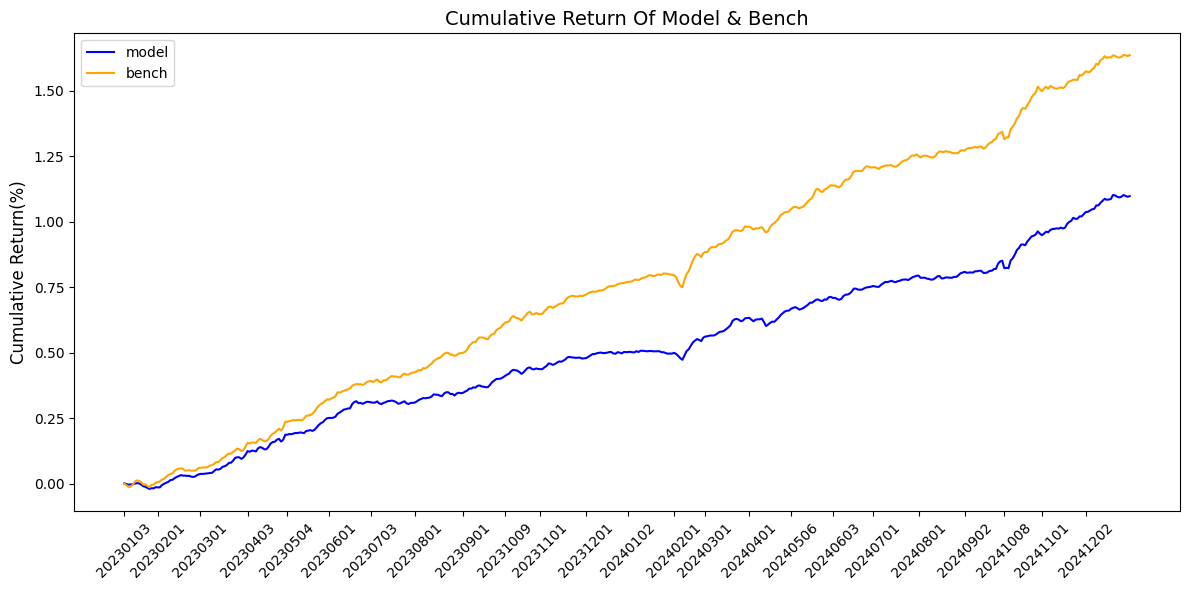

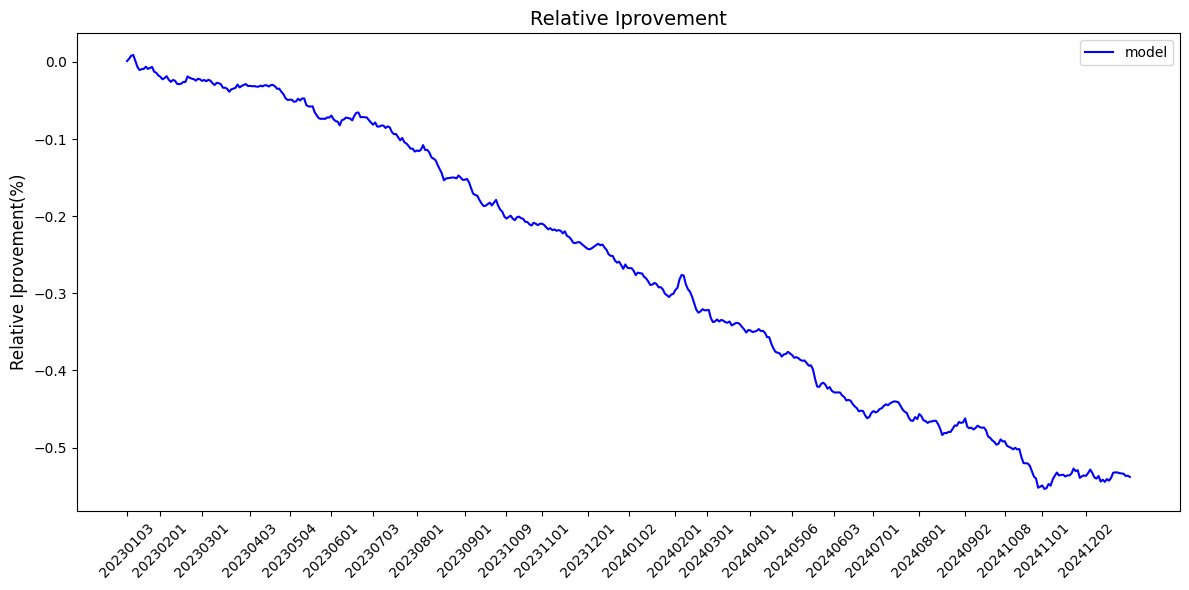

In [5]:
# # 模型路径与结果路径
# root_path = rf'/home/datamake142/model_train_nn/share_1/20250212_实盘测试/shipan3'
# model_test_path = rf'{root_path}/model_test'
# model_res_path = rf'{root_path}/model_res'
# for path in [model_res_path]:
#     os.makedirs(path, exist_ok=True)

# # 收集模型训练结果
# score1 = concat_model_4fold(test_path=model_test_path, res_path=model_res_path) 

score1_df = pd.read_csv(rf'/home/user165/workspace/quant/scores/mlp_spectral_v5_20260409_055017.csv')
# score1_df = pd.read_csv(rf'hhx/code/model_XGBoost_v2/fac_all/scores/fac3001_20260224_224133.csv')
score1_df['date'] = pd.to_datetime(score1_df['date']).dt.strftime('%Y%m%d')
score1_df['Code'] = score1_df['Code'].astype(str).str.zfill(6)
score1_df = score1_df.pivot(index='date', columns='Code', values='score')
score1_df = score1_df.sort_index()
score1_df.index.name = "date"

score1 = score1_df

score1_dates = set(score1_df.index)
bench_dates = set(bench_all.index)
common_dates = sorted(score1_dates & bench_dates)
score1 = score1.loc[common_dates]
bench_all = bench_all.loc[common_dates]



# 单模型效果评估
print("---单一模型评估---")
score1_metrics = get_metrics(score1, params.ret_data, params.liquid_data, start='20230101', end='20250630', money=1.5e9, print_quarterly=True)
print_metrics(score1_metrics)
print("---该模型与现有集成模型的相关性---")
corr_with_bench = score1.reindex(columns=bench_all.columns, index=bench_all.index).corrwith(bench_all, axis=1)
print(f"{corr_with_bench.mean():.4f}")


print("---模型集成评估---")
bench_new = ensemble_scores(bench1, bench2, bench3, bench4, bench5, score1)
de_series = bench_new.groupby('date').apply(diversity_entropy)
print(f'加入当前模型后的多样性熵：{de_series.mean()}')
print('当前模型与现有子模型之间的相关性：')
print(bench_new.groupby('date').corr().unstack().mean().unstack())
print("---与现有子模型集成效果---")
bench_new_metrics = get_metrics(bench_new.mean(axis=1).unstack(), params.ret_data, params.liquid_data, start='20230101', end='20241231', money=1.5e9, print_quarterly=True)
print_metrics(bench_new_metrics, bench_all_metrics)
plot_model(bench_new.mean(axis=1).unstack(), bench_all, params.ret_data, params.liquid_data, start='20230101', end='20241231', money=1.5e9)